In [65]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import emcee
import corner
import h5py
import numpy.ma as ma
from scipy.interpolate import interp1d
import pickle 
import scipy.constants as const
from scipy import interpolate
from multiprocessing import Pool
import arviz as az
from datetime import datetime

## Reading Inp Values from Pickel File

In [85]:
with open('2026-03-26_inp_values_sky_andmndata_GMOSS_70-110.pkl', 'rb') as f:

    inp_values= pickle.load(f) # deserialize using load()
PSky = inp_values["PSky"]
PSky_coeffs = inp_values["PSky_coeffs"]
S11_params = inp_values["S11_params"]
TE_coeffs = inp_values["Tot_eff_coeffs"]
TMeas_clean = inp_values["Real Data"]
act_uncert = inp_values["act_uncert"]
PW_t = inp_values["PW_t"]
PN_t = inp_values["PN_t"]
gN_t = inp_values["gN_t"]
f_t = inp_values["f_t"]
l_t = inp_values["l_t"]
phi_t = inp_values["phi_t"]
v_clean = inp_values["req_freq"]
sig21cm = inp_values["sig21cm"]

In [86]:
def  Compute_Tmeas_Sky(PA_coeffs, S11_params, TE_coeffs, PW, PN, gamma_N, f, l, phi, v):
        
    v=np.array(v)
    A = np.zeros_like(v, dtype=float)
    B = np.zeros_like(v, dtype=float)
    C = np.zeros_like(v, dtype=float)
    l=l
    itr=3
    Tmeas=[]
    phi_A=phi
    phi_N=0
    phi_f=0
    c=const.c
    ##nuisance= nuisance
    # Calculating PA
    #PSky_log=np.polyval(PA_coeffs, np.log10(v))
    P0,P1,P2,P3,P4,P5 = PA_coeffs
    #P0,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11
    PSky_log = np.polyval([P0, P1, P2,  P3, P4,  P5], np.log10(v))
#     np.polyval([P0*1e+01,  P1*1e+02, P2*1e+02,  P3*1e+02, P4*1e+03,  P5*1e+03,\
#                          P6*1e+03, P7*1e+03, P8*1e+04, P9*1e+04, P10*1e+04, P11*1e+04] , np.log10(v))
 
    PA=np.power(10.0, PSky_log, dtype=np.float64)
    
    # Estimating Gamma_A
    p0,p1,p2,p3,p4,p5,p6=S11_params
    gamma_A=np.polyval([p0*1e-11, p1*1e-9, p2*1e-06, p3*1e-04, p4*1e-02, p5*1e-1, p6],v)
    #np.polyval([p0*1e-12, p1*1e-9, p2*1e-07, p3*1e-04, p4*1e-03, p5*1e-1, p6],v)
 
    # Gamma Conversion Factor
    F = (np.sqrt(1-np.abs(gamma_N)**2))/(1-gamma_A * gamma_N)
    
    # Estimating Total Efficieny
    t0,t1,t2,t3,t4,t5,t6,t7=TE_coeffs
    
    Tot_eff = np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GSM TE Coeffs

#     np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
#                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GMOSS TE Coeffs

#     Tot_eff= np.polyval([t0*1e-13, t1*1e-11, t2*1e-9, t3*1e-7, \
#                          t4*1e-5, t5*1e-3, t6*1e-1, t7],v)  ### Ficco TE Coeffs


    phi=(4*math.pi*(v*1e6)*l)/(0.7*c) #frequency should be in Hz
    #print(phi.size)
    for n in range(itr):
        # For A term: l index sum
        l_values = np.arange(n + 1)
        sum_l = np.sum(np.cos((2 * l_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)
        #print(sum_l.size)
        # For C term: c index sum (same structure as A)
        c_values = np.arange(n + 1)
        sum_c = np.sum(np.cos((2 * c_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)

        # Powers
        gammaA_pow_n = np.abs(gamma_A*F)**n
        gammaN_pow_n = np.abs(gamma_N)**n

        # A term update
        A += gammaA_pow_n * gammaN_pow_n * sum_l

        # B term update
        B += 2 * np.abs(f) * (np.abs(gamma_A*F)**(n + 1)) * gammaN_pow_n * \
             np.cos(phi_f + (n + 1)*(phi_A + phi) + n*phi_N)

        # C term update
        C += gammaA_pow_n * gammaN_pow_n * sum_c

    #Tmeas = (PA * A - Pref) + PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * A)
    
    #Tmeas = (PA*(1-np.abs(gamma_A)**2) * A )+ PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * C)
    
    ant_term = PA * (1 - np.abs(gamma_A)**2) * F**2 * Tot_eff * A
    sys_term = PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * C)
    water_term = PW * (1 - (np.abs(gamma_A)**2) - Tot_eff)  
    
    Tmeas = ant_term + sys_term + water_term #+ nuisance*np.cos(phi)
    
    
    return Tmeas
  

In [105]:
def  Compute_Antenna(PA_coeffs, S11_params, TE_coeffs, gamma_N, l, phi, v):
# Compute_Tmeas_Sky(PA_coeffs, S11_params, TE_coeffs, PW, PN, gamma_N, f, l, phi, v):
    req_freq=np.array(v)
    A = np.zeros_like(req_freq, dtype=float)
    B = np.zeros_like(req_freq, dtype=float)
    C = np.zeros_like(req_freq, dtype=float)
    l=l
    itr=3
    Tmeas=[]
    phi_A=phi
    phi_N=0
    phi_f=0
    c=const.c
    ##nuisance= nuisance
    # Calculating PA
    P0,P1,P2,P3,P4,P5 = PA_coeffs
    PSky_log = np.polyval([P0, P1, P2,  P3, P4,  P5], np.log10(v))
#     np.polyval([P0*1e+01,  P1*1e+02, P2*1e+02,  P3*1e+02, P4*1e+03,  P5*1e+03,\
#                          P6*1e+03, P7*1e+03, P8*1e+04, P9*1e+04, P10*1e+04, P11*1e+04] , np.log10(v))
    PA=np.power(10.0, PSky_log, dtype=np.float64)
    
    #estimating Gamma_A
    p0,p1,p2,p3,p4,p5,p6=S11_params
    gamma_A = np.polyval([p0*1e-11, p1*1e-9, p2*1e-06, p3*1e-04, p4*1e-02, p5*1e-1, p6],v)
    #np.polyval([p0*1e-12, p1*1e-9, p2*1e-07, p3*1e-04, p4*1e-03, p5*1e-1, p6],v)
    
    # Gamma Conversion Factor
    F = (np.sqrt(1-np.abs(gamma_N)**2))/(1-gamma_A * gamma_N)
    
    # estimating Total Efficieny
    t0,t1,t2,t3,t4,t5,t6,t7=TE_coeffs
    
    Tot_eff= np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GSM TE Coeffs
#     np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
#                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GMOSS

#     Tot_eff= np.polyval([t0*1e-13, t1*1e-11, t2*1e-9, t3*1e-7, \
#                          t4*1e-5, t5*1e-3, t6*1e-1, t7],v) ### FICCO
    phi=(4*math.pi*(v*1e6)*l)/(0.7*c) #frequency should be in Hz
    #print(phi.size)
    for n in range(itr):
        # For A term: l index sum
        l_values = np.arange(n + 1)
        sum_l = np.sum(np.cos((2 * l_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)
        #print(sum_l.size)
        # For C term: c index sum (same structure as A)
        c_values = np.arange(n + 1)
        sum_c = np.sum(np.cos((2 * c_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)

        # Powers
        gammaA_pow_n = np.abs(gamma_A)**n
        gammaN_pow_n = np.abs(gamma_N)**n

        # A term update
        A += gammaA_pow_n * gammaN_pow_n * sum_l

    
    ant_term = PA * (1 - np.abs(gamma_A)**2) * F**2  * Tot_eff * A
    
    return ant_term

In [106]:
def  Compute_Sys_Water(S11_params, TE_coeffs, PW, PN, gamma_N, f, l, phi, v):
    v=np.array(v)
    A = np.zeros_like(v, dtype=float)
    B = np.zeros_like(v, dtype=float)
    C = np.zeros_like(v, dtype=float)
    l=l
    itr=3
    Tmeas=[]
    phi_A=phi
    phi_N=0
    phi_f=0
    c=const.c
    ##nuisance= nuisance
  
    #estimating Gamma_A
    p0,p1,p2,p3,p4,p5,p6=S11_params
    gamma_A= np.polyval([p0*1e-11, p1*1e-9, p2*1e-06, p3*1e-04, p4*1e-02, p5*1e-1, p6],v)
    #np.polyval([p0*1e-12, p1*1e-9, p2*1e-07, p3*1e-04, p4*1e-03, p5*1e-1, p6],v)
    
    # Gamma Conversion Factor
    F = (np.sqrt(1-np.abs(gamma_N)**2))/(1-gamma_A * gamma_N)
    
    # estimating Total Efficieny
    t0,t1,t2,t3,t4,t5,t6,t7=TE_coeffs
    
    Tot_eff = np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GSM TE Coeffs 
#     np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
#                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GMOSS

#     Tot_eff= np.polyval([t0*1e-13, t1*1e-11, t2*1e-9, t3*1e-7, \
#                          t4*1e-5, t5*1e-3, t6*1e-1, t7],v) ### FICCO
    phi=(4*math.pi*(v*1e6)*l)/(0.7*c) #frequency should be in Hz
    #print(phi.size)
    for n in range(itr):
        # For A term: l index sum
        l_values = np.arange(n + 1)
        sum_l = np.sum(np.cos((2 * l_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)
       
        # For C term: c index sum (same structure as A)
        c_values = np.arange(n + 1)
        sum_c = np.sum(np.cos((2 * c_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)

        # Powers
        gammaA_pow_n = np.abs(gamma_A * F)**n
        gammaN_pow_n = np.abs(gamma_N)**n

        # B term update
        B += 2 * np.abs(f) * (np.abs(gamma_A * F)**(n + 1)) * gammaN_pow_n * \
             np.cos(phi_f + (n + 1)*(phi_A + phi) + n*phi_N)

        # C term update
        C += gammaA_pow_n * gammaN_pow_n * sum_c

    #Tmeas = (PA * A - Pref) + PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * A)
    
    #Tmeas = (PA*(1-np.abs(gamma_A)**2) * A )+ PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * C)
    
    sys_term = PN * (B + (np.abs(f)**2) * (np.abs(gamma_A * F)**2) * C)
    water_term = PW * (1 - (np.abs(gamma_A *F)**2) - Tot_eff)  
    
    sys_wtr_term =  sys_term + water_term #+ nuisance*np.cos(phi)
    
    
    return sys_wtr_term #, (np.abs(gamma_A *F)**2), Tot_eff
  

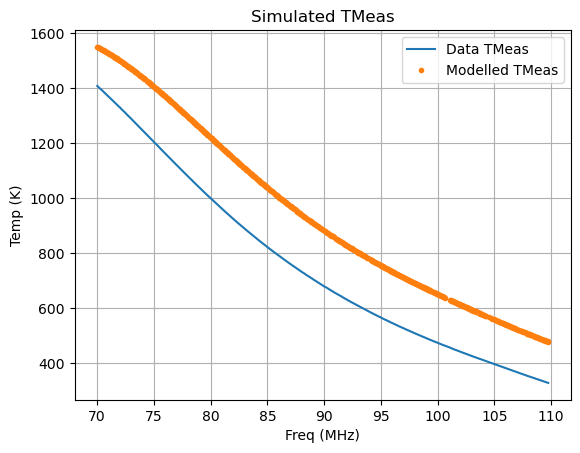

22.755489195810544


In [107]:
#Test Signal
# Parameters
PA_coeffs = PSky_coeffs #PSky_coeffs
S11_params = S11_params
TE_coeffs = TE_coeffs #Tot_eff_coeffs #ficco_tot_eff_coeffs

PW=PW_t
PN=PN_t
gN=gN_t
f=f_t
l=l_t
phi=phi_t

v=v_clean

#nuisance=5

T = Compute_Tmeas_Sky(PA_coeffs, S11_params, TE_coeffs, PW, PN, gN, f, l, phi, v) #, nuisance)
ant = Compute_Antenna(PA_coeffs, S11_params, TE_coeffs, gN, l, phi, v)
sys_wtr=Compute_Sys_Water(S11_params, TE_coeffs, PW, PN, gN, f, l, phi, v)

#plt.plot(v_clean, ant,label="Ant contribution")
plt.plot(v_clean, TMeas_clean,label="Data TMeas")
#plt.plot(v_MHz, avg_masked_TMeas,'.', label="Actual Data")
plt.plot(v_clean, T,'.', label="Modelled TMeas")
#plt.plot(v_clean,sys_wtr , label="Pre Optimization System+ Water term")

#plt.xlim(60,110)
plt.xlabel("Freq (MHz)")
plt.ylabel("Temp (K)")
plt.title("Simulated TMeas")
plt.legend()
plt.grid()
plt.show()
print(np.std(T-TMeas_clean))

## Setting Up input params

In [90]:
seed= 74
np.random.seed(seed)

# True values of the system parameters

PA_true = PSky_coeffs#PSky_coeffs
TE_coeffs= TE_coeffs#Tot_eff_coeffs #ficco_tot_eff_coeffs #
S11_params = S11_params
Ant = Compute_Antenna(PA_true, S11_params, TE_coeffs, gN_t, l_t, phi_t, v_clean)
TMeas_ = Compute_Tmeas_Sky(PA_true, S11_params, TE_coeffs, \
                          PW_t, PN_t, gN_t, f_t, l_t, phi_t, v_clean)#T21
t0,t1,t2,t3,t4,t5,t6,t7 =TE_coeffs
Tot_eff_actual= np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v_clean)

### Actual Uncertainity Data
act_uncert = np.array(act_uncert, dtype=float)

### Adding 21cm to the data
a_actual= 1 

TMeas_exp = TMeas_clean #+ a_actual*sig21cm  #np.array(TMeas_)+uncert+a_actual*sig21cm 
SW_exp=TMeas_exp-Ant


## MCMC with all params (S11 fixed)

In [91]:
########### Define the log-likelihood function
def log_likelihood_full(params, seed, v, s, weights, TA_exp, S11_params, signal):

    np.random.seed(seed)
    
    # Compute model TA

    P0,P1,P2,P3,P4,P5, \
    t0,t1,t2,t3,t4,t5,t6,t7, PW, PN, gamma_N, f, l, phi = params
    
    #PW, PN, gamma_N, f, l, phi = params
    #PSky_log=np.polyval([P0, P1, P2, P3, P4, P5],np.log10(v))
    #with np.errstate(over='ignore'):
     #   PA = np.power(10.0, PSky_log, dtype=np.float64)
    PA_coeffs = P0,P1,P2,P3,P4,P5#,P6,P7,P8,P9,P10,P11
    TE_coeffs = t0,t1,t2,t3,t4,t5,t6,t7
    S11_params = S11_params
    TA_model = Compute_Tmeas_Sky(PA_coeffs, S11_params, TE_coeffs, PW, PN, gamma_N, f, l, phi, v)

    TA_model=np.array(TA_model)#+a*signal #+b*s

    # Compute chi-squared
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 
    #chi2 = np.sum([((TA_exp - TA_model)** 2)*weights ]) 

    return -0.5*chi2 #- np.log(math.sqrt(2*np.pi)*s)

########## Define the log-prior function
def log_prior_full(params, v, debug, PSky, S11_params):

    P0,P1,P2,P3,P4,P5, t0,t1,t2,t3,t4,t5,t6,t7, PW, PN, gamma_N, f, l, phi = params
    #PW, PN, gamma_N,f, l, phi = params
    v=v
    #PA, p0, p1, p2, p3, p4, p5, p6, PN,gamma_N, f, l = params
    #gamma_A=np.polyval([p0*1e-48, p1*1e-39, p2*1e-31, p3*1e-23, p4*1e-15, p5*1e-08, p6*1e-01],v)
    
#     PSky_log=np.polyval([P0, P1, P2, P3, P4, P5],np.log10(v))
#     with np.errstate(over='ignore'):
#         PA= np.power(10.0, PSky_log, dtype=np.float64)
 
    PSky_log =  np.polyval([P0, P1, P2,  P3, P4,  P5], np.log10(v))
#     np.polyval([P0*1e+01,  P1*1e+02, P2*1e+02,  P3*1e+02, P4*1e+03,  P5*1e+03,\
#                          P6*1e+03, P7*1e+03, P8*1e+04, P9*1e+04, P10*1e+04, P11*1e+04] , np.log10(v))
    #with np.errstate(over='ignore'):
    PA=np.power(10.0, PSky_log, dtype=np.float64)
    
    Tot_eff= np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GSM TE Coeffs 
#     np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
#                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v) ### GMOSS
#     Tot_eff= np.polyval([t0*1e-13, t1*1e-11, t2*1e-9, t3*1e-7, \
#                          t4*1e-5, t5*1e-3, t6*1e-1, t7],v) ### FICCO

    p0,p1,p2,p3,p4,p5,p6 = S11_params
    gamma_A = np.polyval([p0*1e-11, p1*1e-9, p2*1e-06, p3*1e-04, p4*1e-02, p5*1e-1, p6],v)
    #np.polyval([p0*1e-12, p1*1e-9, p2*1e-07, p3*1e-04, p4*1e-03, p5*1e-1, p6],v)
    
    F = (np.sqrt(1-np.abs(gamma_N)**2))/(1-gamma_A * gamma_N)
    
    alpha= Tot_eff/(1 - (np.abs(gamma_A *F)**2))
    PSky= PSky
    
    ### Debugging:
#     if not np.all(0<= a <= 1):
#         if debug: print("Prior failed: alpha > 1")
#         return -np.inf
    for i in range(len(v)):
        if not (PA[i]<=PSky[i]*1.5 and PA[i]>=PSky[i]*0.5):
            if debug: print(f"Prior failed: PA= {PA[i],PSky[i]}")
            return -np.inf
#     if not np.all(PA > 0):
#         if debug: print("Prior failed: PA <= 0")
#         return -np.inf
#     if not (min_minus<=np.amin(PA)<=min_plus and max_minus<=np.amax(PA)<=max_plus):
#         if debug: print("Prior failed: PA <= 0")
#         return -np.inf
    for i in range(len(v)):
        if not (Tot_eff[i]<=Tot_eff_actual[i]*1.5 and Tot_eff[i]>=Tot_eff_actual[i]*0.5):
            if debug: print(f"Prior failed: TE= {Tot_eff[i],Tot_eff_actual[i]}")
            return -np.inf
#     if not (np.amin(Tot_eff)>=0 and np.amax(Tot_eff)<=1):
#         if debug: print(f"Prior failed: Tot_eff = {Tot_eff} not >0")
#         return -np.inf
    if not np.all(alpha < 1):
        if debug: print("Prior failed: alpha > 1")
        return -np.inf
    if not (296<PW<313):
        if debug: print(f"Prior failed: PW = {PW} not >0")
        return -np.inf
    if not (PN>0):
        if debug: print(f"Prior failed: PN = {PN} not >0")
        return -np.inf
    if not (0 <= gamma_N <= 1):
        if debug: print(f"Prior failed: gamma_N = {gamma_N} not in [0,1]")
        return -np.inf
    if not (0<f<1):
        if debug: print(f"Prior failed: f = {f} <= 0")
        return -np.inf
    if not (0.0 < l < 0.70):  # fixed the logic — your original had it reversed
        if debug: print(f"Prior failed: l = {l} not in (0.10, 0.70)")
        return -np.inf

    return 0.0

    
######### Define the full log-probability function
    
def log_probability_full(params, seed, v, s, weights, TA_exp, S11_params, debug, PSky, signal):
    lp = log_prior_full(params, v, debug, PSky, S11_params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_full(params, seed, v, s, weights, TA_exp, S11_params, signal)


########## MCMC for RLC Coeffs.
def evolve_MCMC_Full(**kwargs):

    #debug=True
    ## Number of walkers and steps
    ndim = 20 # Number of parameters
    nwalkers = 150  # Number of MCMC walkers
    nsteps = kwargs["nsteps"]  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    
    initials_large=kwargs["initials_large"]
    initials_small=kwargs["initials_small"]
    seed=kwargs["seed"]
    v=kwargs["v"]
    s=kwargs["s"]
    weights=kwargs["weights"]
    TA_exp=kwargs["TA_exp"]
    S11_params = kwargs["Sky_S11_params"]
    signal=kwargs["signal"]
    debug=kwargs["debug"]
    PSky = kwargs["PSky"]
    #f = kwargs["f"]
    #PA_cc=kwargs["PA_Coeffs"]
    #print('128')
    ## Starting positions for the walkers (making sure that the initial positions satisfy the priors)
    np.random.seed(seed+1)
    
    pos_valid = []
    while len(pos_valid) < nwalkers:
        #print('135')
        #trial =np.array(initial_value) + 1e-3 * np.random.normal(size=ndim)# initial_value + 1e-1 * np.random.randn(ndim)
        trial_large = np.array(initials_large) + 1e-1 * np.random.normal(size=len(initials_large))# initial_value + 1e-1 * np.random.randn(ndim)
        trial_small= np.array(initials_small) + 1e-4 * np.random.normal(size=len(initials_small))
        trial_large=list(trial_large)
        trial_small=list(trial_small)

        trial = trial_large[:6] + trial_small + trial_large[6:]
        #print('141')
        if np.isfinite(log_prior_full(trial ,v, debug, PSky, S11_params)):
            #print('143')
            pos_valid.append(trial)
    pos = np.array(pos_valid)
    #print('146')
    #pos = np.array(initial_value)[None,:] + 1e-1*np.random.normal(0,1,size=(nwalkers,ndim))

    ## for making sure only positive positional values
    """
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 
    ## Set up the MCMC sampler
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_full,\
                                        args=(seed, v, s, weights, TA_exp, S11_params, debug, PSky, signal), pool=pool)

        ## Run MCMC

        print("Running MCMC...")
        sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    burn=4500
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=burn, flat=True)
    #tau = sampler.get_autocorr_time(discard=burn, tol=0, quiet=True)
    ## Acceptance Fraction
    af_per_walker = sampler.acceptance_fraction      # array shaped (nwalkers,)
    af_mean = af_per_walker.mean()
    #print("tau (best-effort):", tau)
    #print("tau_max:", np.max(tau))
    
    return full_samples,samples, pos, af_per_walker, af_mean#, tau

#### Initialising MCMC for Full Param run

In [92]:
#evolve MCMC full with initials for system parameters from Open

seed=seed

v=v_clean

P0,P1,P2,P3,P4,P5 = PSky_coeffs #PSky_coeffs #PSky_coeffs  
t0,t1,t2,t3,t4,t5,t6,t7 = TE_coeffs #Tot_eff_coeffs #ficco_tot_eff_coeffs #

## multiplication factor for the signal  
a= 1

## In case initials are taken from best fit of the open run
#PAo, gAo, PNo, gNo, fo, lo, phio= best_fit_o 
#PWf, PNf, gNf, ff, lf, phif = peak_params_free[23:]
#PW_sw, PN_sw, gN_sw, f_sw, l_sw, phi_sw = sw_best_fit_params

##initials for mcmc walkers
full_initials_large=[P0,P1,P2,P3,P4,P5, PW_t, PN_t, gN_t, f_t, l_t, phi_t] 
#full_initials_large=[P0,P1,P2,P3,P4,P5, gN_t, l_t, phi_t] 
full_initials_small= [t0,t1,t2,t3,t4,t5,t6,t7]
full_initials=full_initials_large[:6] + full_initials_small + full_initials_large[6:]

nsteps=5000
PSky = PSky

## 21cm signal
signal= sig21cm 

debug= False

## uncertainity
s=act_uncert

S11_coeffs = S11_params #S11_Sky_coeffs_clean

weights=0

kwargs = {"s":s, "weights":weights, "v":v, "seed":seed, "nsteps":nsteps, "initials_large":full_initials_large, "initials_small":full_initials_small, \
          "TA_exp":TMeas_exp, "Sky_S11_params": S11_params, "signal":signal, "debug":debug, "PSky": PSky}#, "f": f_t} #"ip_params":ip_params}




#### Checking initial values

In [93]:
debug=True
#print(full_initials)
print("Initial value check:", log_prior_full(np.array(full_initials), v_clean, debug, PSky, S11_params))



Initial value check: 0.0


#### MCMC run for full params

In [94]:
full_samples_full, full_samples, full_initial_pos, full_af_per_walker, full_af_mean= evolve_MCMC_Full(**kwargs)

Running MCMC...


100%|███████████████████████████████████████| 5000/5000 [04:38<00:00, 17.93it/s]


#### Computing Max Log Likelihood and Best Fit Params for Full Run

In [95]:
 ## Compute log-likelihoods for all samples
log_likes = np.array([log_likelihood_full(p,seed,v_clean,s,weights,TMeas_exp,S11_params, sig21cm) for p in full_samples])

## Find the index of the maximum likelihood

max_likelihood_index = np.argmax(log_likes)

## Get the best-fit parameters

best_fit_params = full_samples[max_likelihood_index].tolist()

## MCMC for Sys and Water Params

In [ ]:
########### Define the log-likelihood function
def log_likelihood_sw(params, seed, v, s, SW_exp, S11_params, TE_coeffs, gamma_N, l):

    np.random.seed(seed)
    
    # Compute model TA

   
    PW, PN, f, phi = params
    gamma_N = gamma_N
    l = l
    TE_coeffs = TE_coeffs #t0,t1,t2,t3,t4,t5,t6,t7
    S11_params = S11_params
    SW_model = Compute_Sys_Water(S11_params, TE_coeffs, PW, PN, gamma_N, f, l, phi, v)

    SW_model=np.array(SW_model)#+a*signal#+b*s

    # Compute chi-squared
    SW_chi2 = np.sum([((SW_exp - SW_model)/s)** 2 ]) 
    #chi2 = np.sum([((TA_exp - TA_model)** 2)*weights ]) 

    return -0.5*SW_chi2 #- np.log(math.sqrt(2*np.pi)*s)

########## Define the log-prior function
def log_prior_sw(params, v, debug):

    PW, PN, f, phi = params
    v=v
    
#     Tot_eff= np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
#                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v)
#     Tot_eff= np.polyval([t0*1e-13, t1*1e-11, t2*1e-9, t3*1e-7, \
#                          t4*1e-5, t5*1e-3, t6*1e-1, t7],v) r

    ### Debugging:

#     if not (np.amin(Tot_eff)>=0 and np.amax(Tot_eff)<=1):
#         if debug: print(f"Prior failed: Tot_eff = {Tot_eff} not >0")
#         return -np.inf
    if not (250<=PW<=500):
        if debug: print(f"Prior failed: PW = {PW} not >0")
        return -np.inf
    if not (50<=PN<=150):
        if debug: print(f"Prior failed: PN = {PN} not >0")
        return -np.inf
#     if not (0 <= gamma_N <= 1):
#         if debug: print(f"Prior failed: gamma_N = {gamma_N} not in [0,1]")
#         return -np.inf
    if not (0<f<1):
        if debug: print(f"Prior failed: f = {f} <= 0")
        return -np.inf
#     if not (0.1 < l < 0.70):  # fixed the logic — your original had it reversed
#         if debug: print(f"Prior failed: l = {l} not in (0.10, 0.70)")
#         return -np.inf

    return 0.0

    
######### Define the full log-probability function
    
def log_probability_sw(params, seed, v, s, SW_exp, S11_params, TE_coeffs, gamma_N, l, debug):
    lp = log_prior_sw(params, v, debug)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_sw(params, seed, v, s, SW_exp, S11_params, TE_coeffs, gamma_N, l)


########## MCMC for RLC Coeffs.
def evolve_MCMC_SW(**sw_kwargs):

    #debug=True
    ## Number of walkers and steps
    ndim = 4 # Number of parameters
    nwalkers = 150  # Number of MCMC walkers
    nsteps = sw_kwargs["nsteps"]  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    
    initials_large= sw_kwargs["initials_large"]
    #initials_small= sw_kwargs["initials_small"]
    seed= sw_kwargs["seed"]
    v= sw_kwargs["v"]
    s= sw_kwargs["s"]
    #weights= sw_kwargs["weights"]
    SW_exp= sw_kwargs["SW_exp"]
    S11_params = sw_kwargs["Sky_S11_params"]
    TE_coeffs= sw_kwargs["TE_coeffs"]
    gamma_N = sw_kwargs["gamma_N"]
    l=sw_kwargs["l"]
    signal= sw_kwargs["signal"]
    debug= sw_kwargs["debug"]
    #PA_cc=kwargs["PA_Coeffs"]

    ## Starting positions for the walkers (making sure that the initial positions satisfy the priors)
    np.random.seed(seed+1)
    
    pos_valid = []
    while len(pos_valid) < nwalkers:
        #trial =np.array(initial_value) + 1e-3 * np.random.normal(size=ndim)# initial_value + 1e-1 * np.random.randn(ndim)
        trial_large = np.array(initials_large) + 1e-1 * np.random.normal(size=len(initials_large))# initial_value + 1e-1 * np.random.randn(ndim)
        #trial_small= np.array(initials_small) + 1e-4 * np.random.normal(size=len(initials_small))
        trial_large=list(trial_large)
        #trial_small=list(trial_small)
        trial =  trial_large #trial_small +
        if np.isfinite(log_prior_sw(trial ,v, debug)):
            pos_valid.append(trial)
    pos = np.array(pos_valid)
    
    #pos = np.array(initial_value)[None,:] + 1e-1*np.random.normal(0,1,size=(nwalkers,ndim))

    ## for making sure only positive positional values
    """
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 
    ## Set up the MCMC sampler
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_sw,\
                                        args=(seed, v, s, SW_exp, S11_params, TE_coeffs, gamma_N, l, debug), pool=pool)

        ## Run MCMC

        print("Running MCMC...")
        sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    burn=4500
    sw_samples_full=sampler.get_chain()
    sw_samples = sampler.get_chain(discard=burn, flat=True)
    #tau = sampler.get_autocorr_time(discard=burn, tol=0, quiet=True)
    ## Acceptance Fraction
    af_per_walker = sampler.acceptance_fraction      # array shaped (nwalkers,)
    af_mean = af_per_walker.mean()
    #print("tau (best-effort):", tau)
    
    #print("tau_max:", np.max(tau))
    
    
    return sw_samples_full,sw_samples, pos, af_per_walker, af_mean#, tau

### Initialising MCMC for System and Water parameters 

In [34]:
#evolve MCMC for System and Water parameters 

seed=seed

v=v_clean

t0,t1,t2,t3,t4,t5,t6,t7 = TE_coeffs #ficco_tot_eff_coeffs #
#TE_coeffs = GSM_Tot_eff_coeffs
## multiplication factor for the signal  
a=1 

## In case initials are taken from best fit of the open run
#PAo, gAo, PNo, gNo, fo, lo, phio= best_fit_o 
#PWf, PNf, gNf, ff, lf, phif = peak_params_free[23:]

##initials for mcmc walkers
#initials_large=[P0,P1,P2,P3,P4,P5, PW_t, PN_t, gN_t, f_t, l_t, phi_t] 
sw_initials_large = [PW_t, PN_t, f_t, phi_t] 
sw_initials_small = [t0,t1,t2,t3,t4,t5,t6,t7]
sw_initials = sw_initials_large # sw_initials_small +
nsteps=5000 

## 21cm signal
signal= sig21cm 

debug=False

## uncertainity
s=act_uncert

#S11_coeffs = S11_Sky_coeffs

weights=0

sw_kwargs = {"s":s, "v":v, "seed":seed, "nsteps":nsteps, "initials_large":sw_initials_large, "initials_small":sw_initials_small, \
          "SW_exp":SW_exp, "Sky_S11_params": S11_params,"TE_coeffs":TE_coeffs, "gamma_N":gN_t, "l":l_t, "signal":signal, "debug":debug} #"ip_params":ip_params}


#### Checking initial values

In [ ]:
print("Initial value check:", log_prior_sw(np.array(sw_initials), v_clean, debug=True))

#### SW Param run

In [ ]:
sw_samples_full, sw_samples, sw_initial_pos, sw_af_per_walker, sw_af_mean= evolve_MCMC_SW(**sw_kwargs)

#### Computing Max Log Likelihood and Best Fit Params for SW Param Run

In [ ]:
## Compute log-likelihoods for all samples for System and Water Params
sw_log_likes = np.array([log_likelihood_sw(p,seed,v_clean,s,SW_exp,S11_params,TE_coeffs, gN_t, l_t) for p in sw_samples])


## Find the index of the maximum likelihood

sw_max_likelihood_index = np.argmax(sw_log_likes)

## Get the best-fit parameters

sw_best_fit_params = sw_samples[sw_max_likelihood_index].tolist()

## Results

## Full Param MCMC Run

### TMeas Actual vs Observed

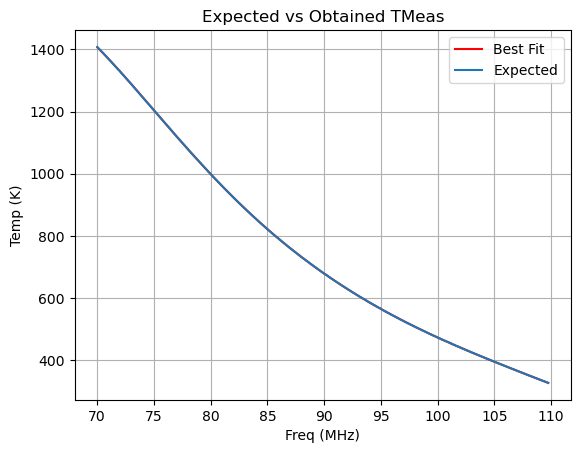

In [96]:
P0_b, P1_b, P2_b, P3_b, P4_b, P5_b, \
t0_b,t1_b,t2_b,t3_b,t4_b,t5_b,t6_b,t7_b, PW_b, PN_b, gN_b, f_b, l_b, phi_b=best_fit_params
#P0, P1, P2, P3, P4, P5, PW, PN, gN, f, l, phi=best_fit_params_fixed
#P0, P1, P2, P3, P4, P5, t0,t1,t2,t3,t4,t5,t6,t7, gN, l, phi=best_fit_params
PSky_cc_best=[P0_b,P1_b,P2_b,P3_b,P4_b,P5_b]
Tot_eff_coeffs_best=[t0_b,t1_b,t2_b,t3_b,t4_b,t5_b,t6_b,t7_b]

TMeas_best = Compute_Tmeas_Sky(PSky_cc_best, S11_params, \
                               Tot_eff_coeffs_best, PW_b, PN_b, gN_b, f_b, l_b, phi_b, v_clean)#+a_b*sig21cm
plt.plot(v_clean,TMeas_best,'r', label="Best Fit")
plt.plot(v_clean,TMeas_exp, label="Expected")
plt.title('Expected vs Obtained TMeas')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.legend()
plt.grid()

#### TMeas Residuals

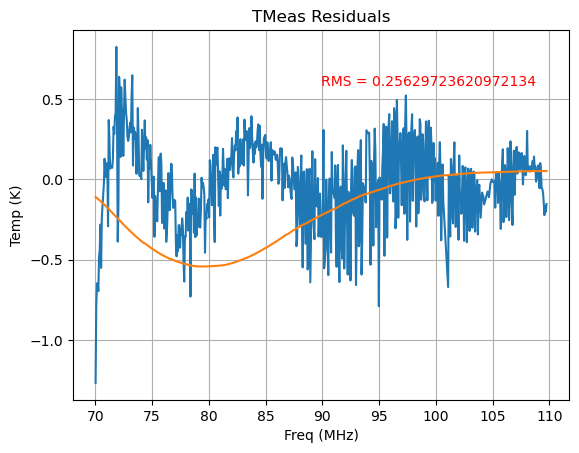

In [97]:
res_TMeas=TMeas_best-TMeas_exp
rms_TMeas=np.std(res_TMeas)
plt.plot(v_clean,res_TMeas)
plt.plot(v_clean, sig21cm)
plt.text(0.5, 0.85, f"RMS = {rms_TMeas}", transform=plt.gca().transAxes,fontsize=10, color='red')
plt.title('TMeas Residuals')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
#plt.xlim(50,110)
plt.grid()
plt.show()

#### Antenna Term Recovery

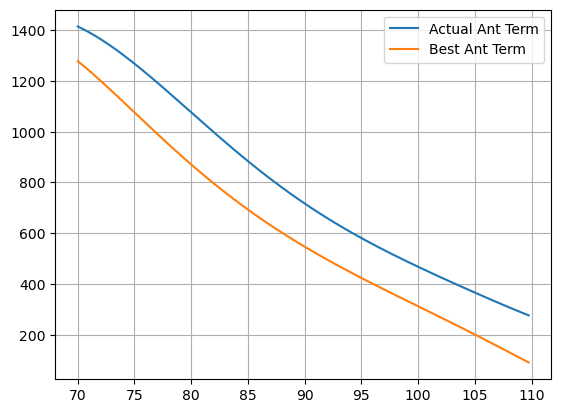

In [98]:
ant_best = Compute_Antenna(PSky_cc_best, S11_params, Tot_eff_coeffs_best, gN_b, l_b, phi_b, v_clean)
sys_wtr_best=Compute_Sys_Water(S11_params, Tot_eff_coeffs_best, PW_b, PN_b, gN_b, f_b, l_b, phi_b, v_clean)
plt.plot(v_clean, ant, label='Actual Ant Term')
plt.plot(v_clean, ant_best, label='Best Ant Term')
plt.legend()
plt.grid()

#### Sys + Water Contribution Recovery

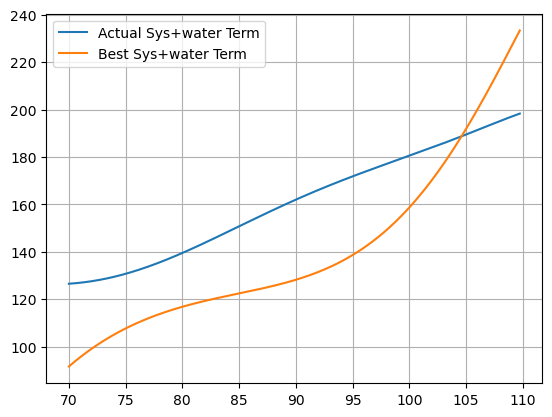

In [99]:
plt.plot(v_clean, sys_wtr, label='Actual Sys+water Term')
plt.plot(v_clean, sys_wtr_best, label='Best Sys+water Term')
plt.legend()
plt.grid()

### PSky Actual vs Obtained

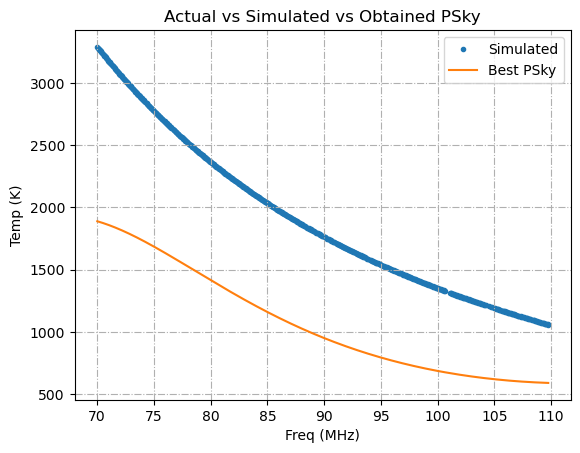

In [108]:
# Actual vs Simulated vs Obtained PSky
PSky_log=np.polyval(PSky_cc_best ,np.log10(v_clean))
with np.errstate(over='ignore'):
    PA_best= np.power(10.0, PSky_log, dtype=np.float64)

plt.plot(v_clean, PSky,'.', zorder=-1, label="Simulated")
plt.plot(v_clean, PA_best, label='Best PSky')
#plt.loglog(v_clean, PA_best)
plt.title('Actual vs Simulated vs Obtained PSky')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.legend()
plt.grid(linestyle='-.')


### Tot Eff Actual vs Obtained

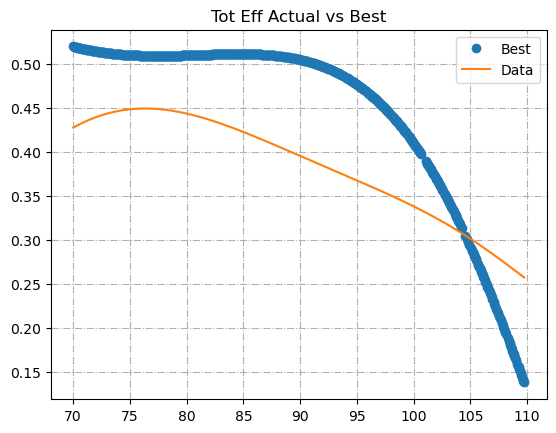

In [109]:
t0,t1,t2,t3,t4,t5,t6,t7 =Tot_eff_coeffs_best
Tot_eff_best= np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v_clean)
t0,t1,t2,t3,t4,t5,t6,t7 =TE_coeffs
Tot_eff_actual= np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, \
                          t4*1e-3, t5*1e-1, t6, t7*1e+1],v_clean)
#np.polyval([t0*1e-12, t1*1e-9, t2*1e-7, t3*1e-5, t4*1e-3, t5*1e-1, t6, t7*1e+1],v_clean) 

#np.polyval([t0*1e-13, t1*1e-11, t2*1e-9, t3*1e-7, \
                         # t4*1e-5, t5*1e-3, t6*1e-1, t7],v_clean)


plt.plot(v_clean, Tot_eff_best, 'o', label="Best")
plt.plot(v_clean, Tot_eff_actual, label="Data")
plt.title('Tot Eff Actual vs Best')
plt.legend()
plt.grid(linestyle='-.')

In [ ]:
print(len(parameter_names))

### Histogram of all params

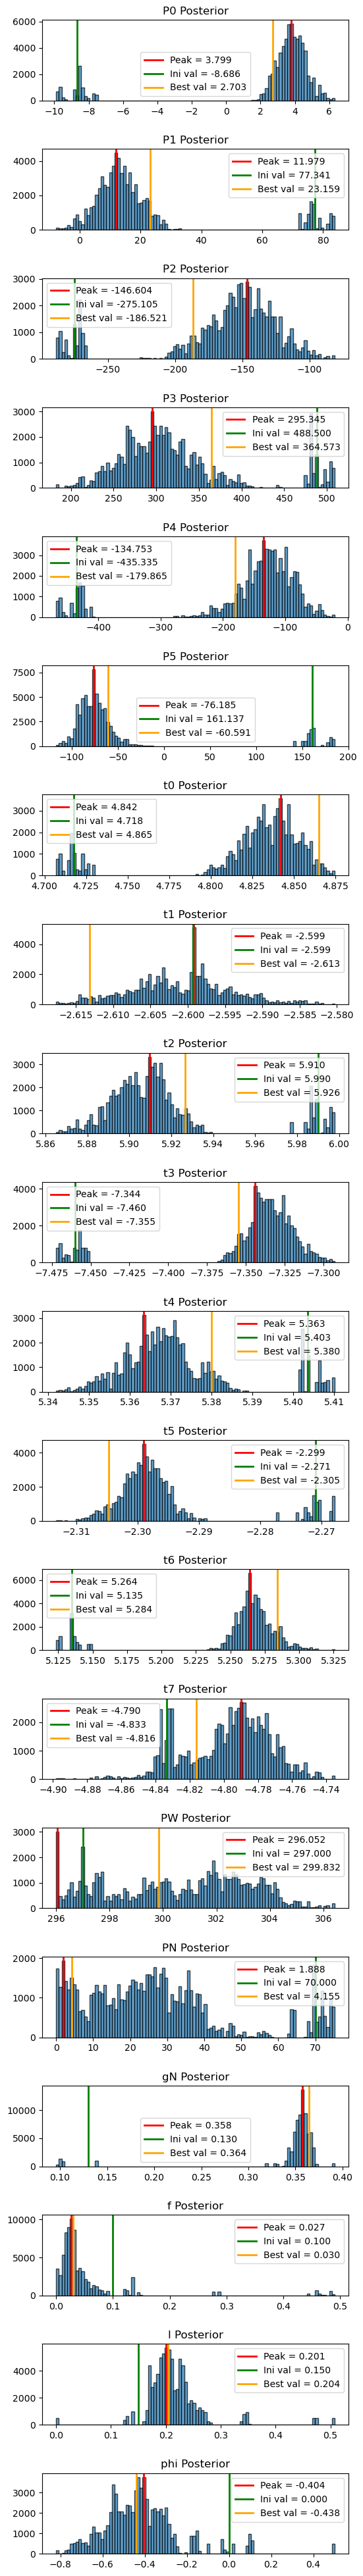

In [110]:
ndim=len(best_fit_params)
parameter_names=["P0", "P1", "P2", "P3", "P4", "P5", "t0","t1","t2","t3",\
   "t4","t5","t6","t7", "PW", "PN", "gN", "f", "l", "phi"]
#p=["P0", "P1", "P2", "P3", "P4", "P5", "PW", "PN", "gN", "f", "l", "phi"]    
params=np.zeros((ndim,ndim))
peak_param=np.zeros(ndim)
#y_max=0 #np.zeros(ndim)
y_max=np.zeros(ndim)
fig, axes = plt.subplots(nrows=ndim, ncols=1, figsize=(6, 2.5 * ndim))
plt.subplots_adjust(hspace=0.6 )
for i in range(ndim):
    counts, bin_edges = np.histogram(full_samples[:,i], bins=100)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Plot as a bar histogram
    
    # Find index of maximum bin
    idx_max = np.argmax(counts)

    #y_max = bin_edges[idx_max]
    
    y_max[i] = (bin_edges[idx_max] + bin_edges[idx_max + 1]) / 2
    
    ind=np.argmin(np.abs(full_samples[:,i]-y_max[i]))
    peak_param[i]=full_samples[ind,i]
    params[i,:]= full_samples[ind,:] ### Total set of parameters corresponding to the maxima achieved in individual param
    ax=axes[i]
    ax.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', alpha=0.7, edgecolor='black')
    ax.axvline(y_max[i], color='r', linewidth=2, label=f"Peak = {y_max[i]:.3f}")
    ax.axvline(full_initials[i], color='g', linewidth=2, label=f"Ini val = {full_initials[i]:.3f}")
    ax.axvline(best_fit_params[i], color='orange', linewidth=2, label=f"Best val = {best_fit_params[i]:.3f}")
    ax.set_title(f"{parameter_names[i]} Posterior")
    ax.legend()


plt.show()

## SW MCMC Run 

### SW Contributions Actual vs Observed

In [ ]:
PW_swb, PN_swb, f_swb, phi_swb = sw_best_fit_params
#sw_TE_coeff_best = t0,t1,t2,t3,t4,t5,t6,t7
SW_best=Compute_Sys_Water(S11_params, TE_coeffs, PW_swb, PN_swb, gN_t, f, l_t, phi_swb, v_clean )
plt.plot(v_clean, SW_best, label="Recovered Sys+ Water Contribution")
plt.plot(v_clean, SW_exp, label= "Actual Sys+ Water Contribution")
plt.title("Actual vs Obtained Sys+Water Contribution")
plt.legend()
plt.grid()
plt.show()

In [ ]:
PW_swb, PN_swb, f_swb, phi_swb

### TMeas Actual vs Observed

In [ ]:
SW_TMeas_best = Compute_Tmeas_Sky(PSky_coeffs, S11_params, \
                               TE_coeffs, PW_swb, PN_swb, f_swb, gN,l, phi_swb, v_clean)#+a*sig21cm
plt.plot(v_clean, SW_TMeas_best, label="TMeas Obtained")
#plt.plot(v_clean, TMeas_exp, label='Actual TMeas')
plt.legend()
plt.grid()

## Saving Pickel Files

## Full MCMC Run File

In [63]:
#Saving in a pickel file
# Ask user for confirmation
now = datetime.now()
date_string = now.strftime("%Y-%m-%d")
parameter_names = parameter_names
    #["P0", "P1", "P2", "P3", "P4", "P5", "t0","t1","t2","t3",\
#    "t4","t5","t6","t7", "PW", "PN", "gN", "f", "l", "phi"]

true_params=[a, PSky_coeffs, S11_params, TE_coeffs, PW_t, PN_t, gN_t, f_t, l_t, phi_t]
seed=seed
print(seed)
#confirm = input("Do you want to save the pickle file? (y/n): ").strip().lower()
confirm="y"
if confirm == "y":
    result={"seed":seed, "req_freq":v_clean, "full_samples":full_samples_full, "samples":full_samples, "best_fit":best_fit_params,\
            "param_names":parameter_names, "true_params":true_params, "S11_params": S11_params, "Real Data":TMeas_exp, "sig21cm": sig21cm}#,"Mean Acceptance Factor":af_mean, "Auto corr time":tau}

    with open(f"{date_string}_results_sky_{seed}_a1s1_andmndata.pkl", 'wb') as file:  # open a text file
        pickle.dump(result, file) # serialize the list

    file.close()
else:
     print("Save cancelled.")

72


## SW MCMC Run File

In [ ]:
#Saving S11 fixed and Tot Eff fixed run results in a pickel file
# Ask user for confirmation
now = datetime.now()
date_string = now.strftime("%Y-%m-%d")
parameter_names_fixed = ["P0", "P1", "P2", "P3", "P4", "P5",\
                   "PW", "PN", "gN", "f", "l", "phi"]
true_params_fixed=[PSky_coeffs, S11_Sky_coeffs_clean, Tot_eff_coeffs, PW_t, PN_t, gN_t, f_t, l_t, phi_t]
seed=seed
print(seed)
#confirm = input("Do you want to save the pickle file? (y/n): ").strip().lower()
confirm="y"
if confirm == "y":
    result={"seed":seed, "req_freq":v_clean, "full_samples":full_samples_fixed, "samples":samples_fixed, "best_fit":best_fit_params_fixed,\
            "param_names":parameter_names_fixed, "true_params":true_params_fixed, "S11_params": S11_Sky_coeffs_clean, "Real Data":TMeas_exp, "sig21cm": sig21cm}#,"Mean Acceptance Factor":af_mean, "Auto corr time":tau}

    with open(f"{date_string}_results_sky_{seed}_s11_TE_fixed_andmndata.pkl", 'wb') as file:  # open a text file
        pickle.dump(result, file) # serialize the list

    file.close()
else:
     print("Save cancelled.")